## Chargement et explotation initiale

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("train.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.head()

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Nettoyage

In [3]:
# Suppression colonnes inutiles
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Imputation
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Vérification
print(df.isnull().sum())
print(df.shape)

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
(891, 8)


## Feature Engineering

In [4]:
# Taille de la famille (seul ou accompagné ?)
df["family_size"] = df["SibSp"] + df["Parch"] + 1  # +1 pour le passager lui-même

# Passager seul ?
df["is_alone"] = (df["family_size"] == 1).astype(int)

# Tranches d'âge
df["age_bucket"] = pd.cut(df["Age"],
                           bins=[0, 12, 18, 35, 60, 100],
                           labels=["enfant", "ado", "jeune adulte", "adulte", "senior"])

print(df[["family_size", "is_alone", "age_bucket"]].head(10))
print(df["age_bucket"].value_counts())

   family_size  is_alone    age_bucket
0            2         0  jeune adulte
1            2         0        adulte
2            1         1  jeune adulte
3            2         0  jeune adulte
4            1         1  jeune adulte
5            1         1  jeune adulte
6            1         1        adulte
7            5         0        enfant
8            3         0  jeune adulte
9            2         0           ado
age_bucket
jeune adulte    535
adulte          195
ado              70
enfant           69
senior           22
Name: count, dtype: int64


## Visualisations

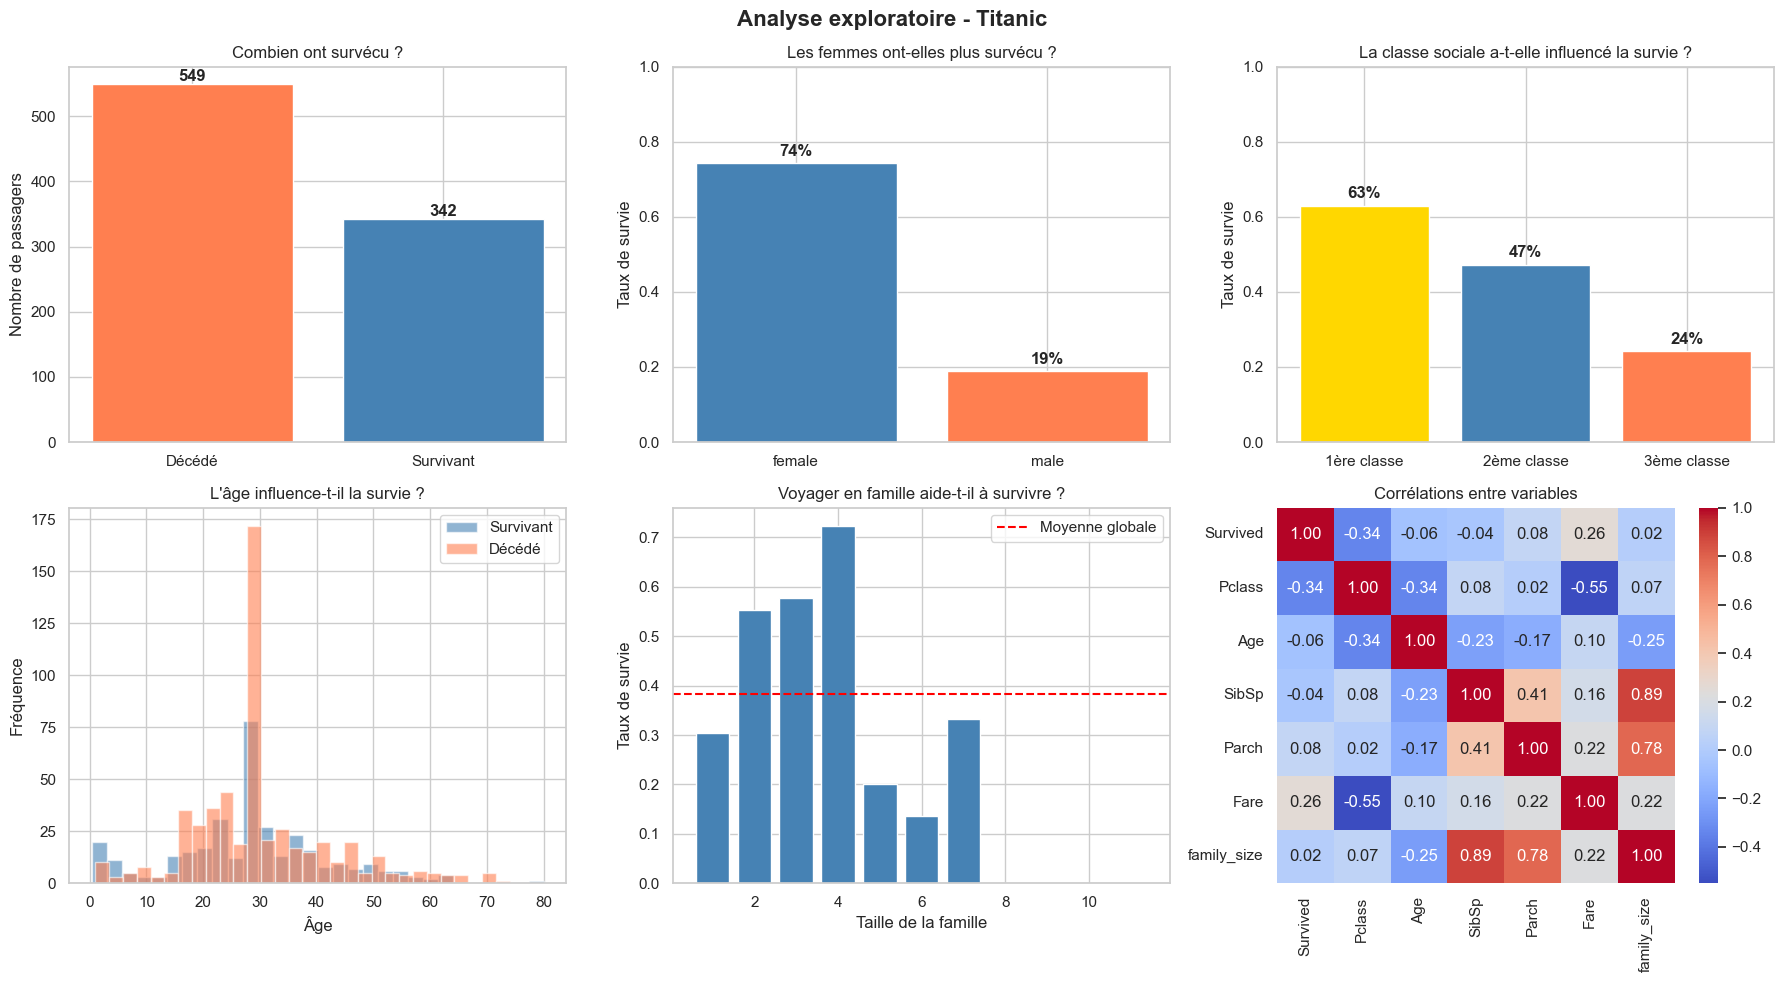

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Analyse exploratoire - Titanic", fontsize=16, fontweight="bold")

# --- 1. Taux de survie global ---
survival_counts = df["Survived"].value_counts()
axes[0, 0].bar(["Décédé", "Survivant"], survival_counts.values,
               color=["coral", "steelblue"], edgecolor="white")
axes[0, 0].set_title("Combien ont survécu ?")
axes[0, 0].set_ylabel("Nombre de passagers")
for i, v in enumerate(survival_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# --- 2. Taux de survie par sexe ---
survival_by_sex = df.groupby("Sex")["Survived"].mean()
axes[0, 1].bar(survival_by_sex.index, survival_by_sex.values,
               color=["steelblue", "coral"], edgecolor="white")
axes[0, 1].set_title("Les femmes ont-elles plus survécu ?")
axes[0, 1].set_ylabel("Taux de survie")
axes[0, 1].set_ylim(0, 1)
for i, v in enumerate(survival_by_sex.values):
    axes[0, 1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# --- 3. Taux de survie par classe ---
survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[0, 2].bar(["1ère classe", "2ème classe", "3ème classe"],
               survival_by_class.values,
               color=["gold", "steelblue", "coral"], edgecolor="white")
axes[0, 2].set_title("La classe sociale a-t-elle influencé la survie ?")
axes[0, 2].set_ylabel("Taux de survie")
axes[0, 2].set_ylim(0, 1)
for i, v in enumerate(survival_by_class.values):
    axes[0, 2].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# --- 4. Distribution des âges par survie ---
df[df["Survived"] == 1]["Age"].hist(ax=axes[1, 0], bins=30, alpha=0.6,
                                     color="steelblue", label="Survivant")
df[df["Survived"] == 0]["Age"].hist(ax=axes[1, 0], bins=30, alpha=0.6,
                                     color="coral", label="Décédé")
axes[1, 0].set_title("L'âge influence-t-il la survie ?")
axes[1, 0].set_xlabel("Âge")
axes[1, 0].set_ylabel("Fréquence")
axes[1, 0].legend()

# --- 5. Survie par taille de famille ---
survival_by_family = df.groupby("family_size")["Survived"].mean()
axes[1, 1].bar(survival_by_family.index, survival_by_family.values,
               color="steelblue", edgecolor="white")
axes[1, 1].set_title("Voyager en famille aide-t-il à survivre ?")
axes[1, 1].set_xlabel("Taille de la famille")
axes[1, 1].set_ylabel("Taux de survie")
axes[1, 1].axhline(df["Survived"].mean(), color="red",
                    linestyle="--", label="Moyenne globale")
axes[1, 1].legend()

# --- 6. Heatmap corrélation ---
corr = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "family_size"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Corrélations entre variables")

plt.tight_layout()
plt.show()